In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
# plt.style.use('../../../foresight.mplstyle')


/home/brendan/OneDrive/Masters/Code/Vortices/Julia/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model = src.models.FNS
fixed_params = {
    'N_e': 1000,
    'J_e': 0.0008,
    'n_ext': 100,
    'omega_ee': 0.036,
    'omega_ei': 0.0564,
    'omega_ie': 0.0444,
    'omega_ii': 0.078,
}
monitors = ['E.spike', 'E.V']
stats = {"rate": src.utils.firing_rate,
         "susceptibility": src.utils.susceptibility(10),
         "spike_spectrum": src.utils.spike_spectrum(10),
         }
duration = 1000.0
transient = 200.0

run = src.models.create_run(model, fixed_params, monitors, duration, transient)
stats_run = src.models.create_stats_run(run, stats)

params = {
    'nu': jnp.array([8.0, 10.0]),
    'delta': jnp.array([4.0, 4.0]),
    'key': jax.random.split(jax.random.PRNGKey(42), 2)
    # 'key': jnp.repeat(jax.random.PRNGKey(42)[None, :], 2, axis=0)
}

# result = jax.vmap(run)(params)

In [3]:
result = stats_run(params)

Predict 10000 steps: :   0%|          | 0/10000 [00:00<?, ?it/s]


In [4]:
result['spike_spectrum']['E.spike'][1]

Array([0.00116863, 0.00032863, 0.00097037, ..., 0.00033159, 0.00097037,
       0.00032863], dtype=float32)

(0.0, 100.0)

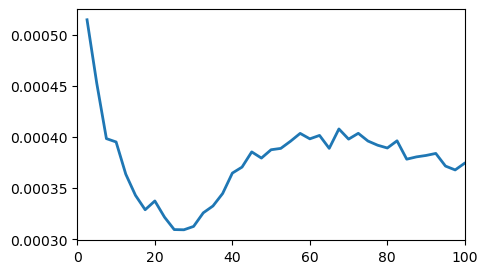

In [5]:
# * Plot the spike spectrum

fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(111)
spectrum = result['spike_spectrum']['E.spike'][0]
freqs = jnp.fft.fftfreq(spectrum.shape[0], bp.share["dt"]/1000)
idxs = freqs > 0
ax.plot(freqs[idxs], spectrum[idxs], lw=2)
ax.set_xlim(0, 100)
